# The Clever Bits

Three design choices separate ColBERT from "BERT + MaxSim": marker tokens, dimensionality reduction, and query augmentation. This notebook shows each one in isolation, then combines them.

**Estimated runtime:** ~3 minutes (mostly model loading)

In [42]:
%pip install torch transformers matplotlib seaborn numpy

import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
from colbert_from_scratch.maxsim import maxsim_np, maxsim_torch
from part2.tokenize import (
    tokenize_query, tokenize_document, tokenize_query_with_n_masks,
    get_token_labels, filter_doc_tokens
)
from part2.encoder import ColBERTEncoder

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Device: mps


In [43]:
# Load model, tokenizer, and toy dataset
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")
bert.eval()
bert.to(device)

with open("../data/toy_retrieval.json") as f:
    dataset = json.load(f)

documents = {doc["id"]: doc["text"] for doc in dataset["documents"]}
queries = {q["id"]: q for q in dataset["queries"]}


def encode_tokens_raw(text):
    """Part 1 style: raw BERT embeddings, no markers, no projection."""
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = bert(**inputs)
    emb = outputs.last_hidden_state.squeeze(0).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze(0).cpu())
    return emb, tokens


print("Model loaded. Toy dataset has", len(documents), "documents and", len(queries), "queries.")

Model loaded. Toy dataset has 10 documents and 5 queries.


## Recap: Part 1 showed MaxSim works with generic BERT

In notebooks 01-03, raw `bert-base-uncased` embeddings (768-dim, no fine-tuning) and MaxSim already disambiguated "python the language" from "python the snake." BERT wasn't trained for retrieval, yet token-level matching caught what bi-encoders missed.

But generic embeddings aren't *optimized* for retrieval. This notebook adds the three things that make them retrieval-aware:

1. `[Q]` and `[D]` marker tokens, which tell BERT which sequence is a query
2. 768 to 128 projection, compressing embeddings 6x with negligible quality loss
3. `[MASK]` query augmentation, padding every query to 32 tokens

Each design choice is shown in isolation before combining them.

## Design choice 1: Tell BERT which sequence is a query

ColBERT prepends special marker tokens to distinguish queries from documents:

```
Query:    [CLS] [Q] who created python [SEP]
Document: [CLS] [D] the python programming language was... [SEP]
```

`[Q]` is token ID 1 (`[unused0]` in BERT's vocabulary). `[D]` is token ID 2 (`[unused1]`). These are vocabulary slots that BERT never saw during pre-training. Their embeddings start random and become trainable parameters during ColBERT fine-tuning.

They serve two purposes: they signal query-vs-document to self-attention, and after training, their learned embeddings shift the representation space to separate query and document regions.

To isolate the marker effect, the comparison below uses scores with and without `[Q]`/`[D]`, but *without* `[MASK]` padding (that's a separate design choice, shown next).

In [44]:
# Side-by-side: tokenization WITHOUT markers vs WITH markers (no [MASK] yet)

query_text = "Who created the Python programming language?"
doc_text = documents[0]

# Part 1 style — standard BERT tokenization
standard_q = tokenizer.encode(query_text, add_special_tokens=True)
standard_d = tokenizer.encode(doc_text, add_special_tokens=True)

# With markers only (no [MASK] padding) — isolates the marker effect
markers_only_q = tokenize_query_with_n_masks(query_text, tokenizer, n_masks=0)
colbert_d = tokenize_document(doc_text, tokenizer, max_length=180)

# Full ColBERT format (markers + [MASK] padding to 32) — shown for reference
full_colbert_q = tokenize_query(query_text, tokenizer, max_length=32)

print("=== Query tokenization ===")
print(f"Standard:      {tokenizer.convert_ids_to_tokens(standard_q)}")
markers_ids = markers_only_q['input_ids'].squeeze(0).tolist()
markers_labels = tokenizer.convert_ids_to_tokens(markers_ids)
markers_labels = ["[Q]" if t == "[unused0]" else t for t in markers_labels]
print(f"With [Q] only: {markers_labels}")
print(f"Full ColBERT:  {get_token_labels(query_text, tokenizer, mode='query')}")
print(f"\nStandard: {len(standard_q)} tokens | With [Q]: {markers_only_q['input_ids'].shape[1]} tokens | Full ColBERT: {full_colbert_q['input_ids'].shape[1]} tokens")

print("\n=== Document tokenization ===")
print(f"Standard: {tokenizer.convert_ids_to_tokens(standard_d)}")
print(f"With [D]: {get_token_labels(doc_text, tokenizer, mode='document')}")

=== Query tokenization ===
Standard:      ['[CLS]', 'who', 'created', 'the', 'python', 'programming', 'language', '?', '[SEP]']
With [Q] only: ['[CLS]', '[Q]', 'who', 'created', 'the', 'python', 'programming', 'language', '?', '[SEP]']
Full ColBERT:  ['[CLS]', '[Q]', 'who', 'created', 'the', 'python', 'programming', 'language', '?', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]']

Standard: 9 tokens | With [Q]: 10 tokens | Full ColBERT: 32 tokens

=== Document tokenization ===
Standard: ['[CLS]', 'the', 'python', 'programming', 'language', 'was', 'created', 'by', 'guido', 'van', 'ross', '##um', 'in', '1991', '.', 'it', 'was', 'designed', 'to', 'be', 'easy', 'to', 'read', 'and', 'simple', 'to', 'implement', '.', '[SEP]']
With [D]: ['[CLS]', '[D]', 'the', 'python', 'programming', 'language', 'was', 'created', 

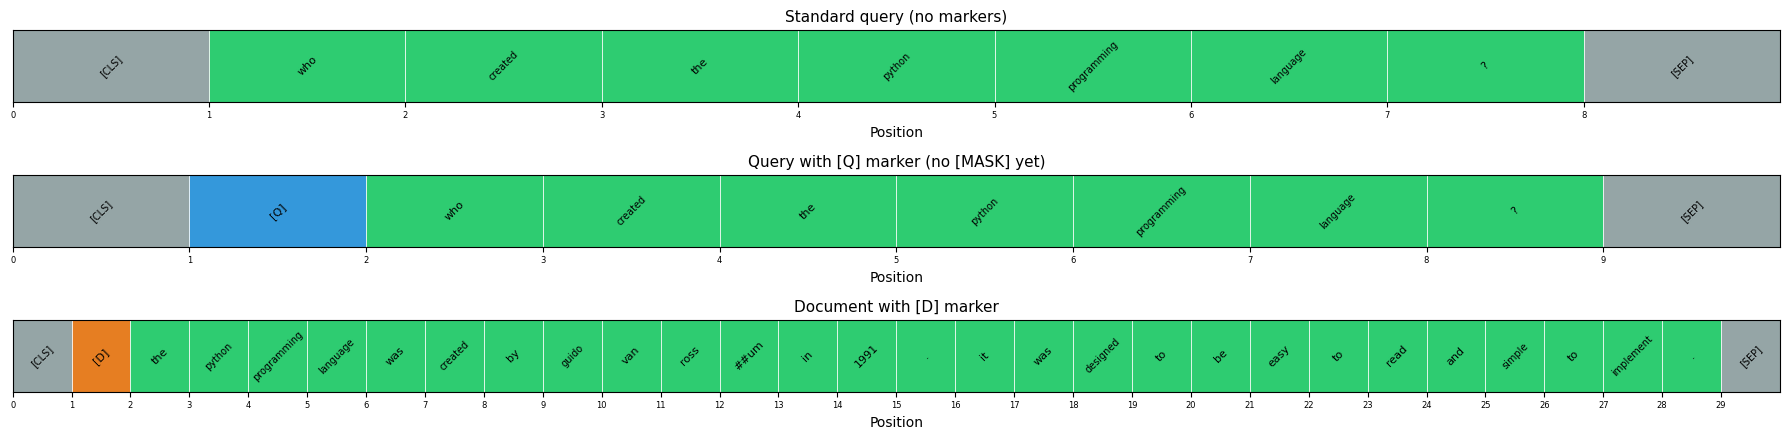

In [45]:
# Visualize the token sequences as colored strips

def plot_token_strip(tokens, title, ax):
    """Draw a horizontal strip of colored tokens."""
    colors = {
        "[CLS]": "#95a5a6", "[SEP]": "#95a5a6", "[PAD]": "#ecf0f1",
        "[Q]": "#3498db", "[D]": "#e67e22", "[MASK]": "#bdc3c7",
    }
    for i, tok in enumerate(tokens):
        color = colors.get(tok, "#2ecc71")
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor="white", linewidth=0.5))
        fontsize = 7 if len(tok) > 4 else 8
        ax.text(i + 0.5, 0.5, tok, ha="center", va="center", fontsize=fontsize, rotation=45)
    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.set_yticks([])
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(range(len(tokens)), fontsize=6)
    ax.set_xlabel("Position")

# Show: standard query, query with [Q] only, document with [D]
standard_labels = tokenizer.convert_ids_to_tokens(standard_q)
d_labels = get_token_labels(doc_text, tokenizer, mode="document")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 4.5))
plot_token_strip(standard_labels, 'Standard query (no markers)', ax1)
plot_token_strip(markers_labels, 'Query with [Q] marker (no [MASK] yet)', ax2)
plot_token_strip(d_labels, 'Document with [D] marker', ax3)
plt.tight_layout()
fig.savefig("../figures/04_token_sequences.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# Compare MaxSim rankings with vs without markers on the toy dataset
# Using raw BERT (no fine-tuning), so markers are untrained [unused] tokens.
# We use n_masks=0 and skip document filtering to isolate the marker effect.

def encode_with_markers_only(text, mode="query"):
    """Encode with [Q]/[D] markers but NO [MASK] padding, NO doc filtering."""
    if mode == "query":
        encoded = tokenize_query_with_n_masks(text, tokenizer, n_masks=0)
    else:
        encoded = tokenize_document(text, tokenizer, max_length=180)
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = bert(**encoded)
    emb = outputs.last_hidden_state.squeeze(0).cpu().numpy()
    return emb


# For each query: score all 10 docs with and without markers, compare rankings
print(f"{'Query':<45}  {'Rank (no mark)':>14}  {'Rank (marked)':>14}  {'Changed?'}")
print("-" * 85)

for q in dataset["queries"]:
    q_emb_raw, _ = encode_tokens_raw(q["text"])
    q_emb_mark = encode_with_markers_only(q["text"], mode="query")

    scores_raw = []
    scores_mark = []
    for doc in dataset["documents"]:
        d_emb_raw, _ = encode_tokens_raw(doc["text"])
        d_emb_mark = encode_with_markers_only(doc["text"], mode="document")
        scores_raw.append((doc["id"], maxsim_np(q_emb_raw, d_emb_raw, normalize=True)))
        scores_mark.append((doc["id"], maxsim_np(q_emb_mark, d_emb_mark, normalize=True)))

    # Compute ranks
    scores_raw.sort(key=lambda x: -x[1])
    scores_mark.sort(key=lambda x: -x[1])
    ranks_raw = {did: r + 1 for r, (did, _) in enumerate(scores_raw)}
    ranks_mark = {did: r + 1 for r, (did, _) in enumerate(scores_mark)}

    rel_id = q["relevant"][0]
    rank_raw = ranks_raw[rel_id]
    rank_mark = ranks_mark[rel_id]
    changed = "YES" if rank_raw != rank_mark else "no"
    print(f"{q['text']:<45}  doc {rel_id} @ rank {rank_raw:>2}    doc {rel_id} @ rank {rank_mark:>2}    {changed}")

print("\nAbsolute scores shift slightly (the [Q] token adds its own MaxSim contribution),")
print("but rankings are mostly unchanged — untrained markers are near-inert.")

Query                                          Rank (no mark)   Rank (marked)  Changed?
-------------------------------------------------------------------------------------
Who created the Python programming language?   doc 0 @ rank  1    doc 0 @ rank  1    no
What is the longest snake species?             doc 9 @ rank  1    doc 9 @ rank  1    no
Where did the creator of Python work?          doc 2 @ rank  1    doc 2 @ rank  1    no
What do machine learning models need?          doc 3 @ rank  1    doc 3 @ rank  1    no
Which programming languages are most popular?  doc 5 @ rank  1    doc 5 @ rank  1    no

Absolute scores shift slightly (the [Q] token adds its own MaxSim contribution),
but rankings are mostly unchanged — untrained markers are near-inert.


With an untrained BERT, the `[Q]` and `[D]` markers are just random `[unused]` tokens. They shift scores slightly but don't help ranking. After fine-tuning (notebook 05), they learn to separate query and document embedding spaces, and the effect becomes real.

---

## Design choice 2: Compress to 128 dimensions

After BERT produces 768-dim token embeddings, ColBERT projects them to 128 dimensions:
- No bias
- No activation function
- L2 normalize afterward so dot products = cosine similarity

This drops 83% of dimensions. Quality barely changes.

In [47]:
# The projection layer — this is the entire thing

encoder = ColBERTEncoder(bert, dim=128)
encoder.eval()
encoder.to(device)

print(f"Projection layer: {encoder.projection}")
print(f"  Weight shape: {encoder.projection.weight.shape}")
print(f"  Bias: {encoder.projection.bias}")  # None — no bias by design

# Count parameters
bert_params = sum(p.numel() for p in encoder.bert.parameters())
proj_params = sum(p.numel() for p in encoder.projection.parameters())
print(f"\nBERT parameters:       {bert_params:>12,}")
print(f"Projection parameters: {proj_params:>12,}  ({768} x {128} = {768*128:,})")
print(f"Total:                 {bert_params + proj_params:>12,}")

Projection layer: Linear(in_features=768, out_features=128, bias=False)
  Weight shape: torch.Size([128, 768])
  Bias: None

BERT parameters:        109,482,240
Projection parameters:       98,304  (768 x 128 = 98,304)
Total:                  109,580,544


In [48]:
# Storage comparison: 768-dim vs 128-dim at scale

avg_tokens = 60
n_docs = 1_000_000

storage_768 = n_docs * avg_tokens * 768 * 4  # float32
storage_128 = n_docs * avg_tokens * 128 * 4

print("=== Storage for 1M documents (avg 60 tokens/doc) ===")
print(f"768-dim: {n_docs:,} x {avg_tokens} x 768 x 4 bytes = {storage_768 / 1e9:.1f} GB")
print(f"128-dim: {n_docs:,} x {avg_tokens} x 128 x 4 bytes = {storage_128 / 1e9:.1f} GB")
print(f"Reduction: {storage_768 / storage_128:.1f}x smaller")

=== Storage for 1M documents (avg 60 tokens/doc) ===
768-dim: 1,000,000 x 60 x 768 x 4 bytes = 184.3 GB
128-dim: 1,000,000 x 60 x 128 x 4 bytes = 30.7 GB
Reduction: 6.0x smaller


In [49]:
# Show that projection barely changes the heatmap
# Compare Part 1 (768-dim raw BERT) vs projected (128-dim) on the same query-doc pair

q0 = queries["q0"]
Q_768, q_tokens_768 = encode_tokens_raw(q0["text"])
D_768, d_tokens_768 = encode_tokens_raw(documents[0])

# Projected: run through encoder (random projection, untrained)
q_encoded = tokenizer(q0["text"], return_tensors="pt", truncation=True)
d_encoded = tokenizer(documents[0], return_tensors="pt", truncation=True)

# Only keep input_ids and attention_mask (encoder doesn't accept token_type_ids)
q_enc = {k: v.to(device) for k, v in q_encoded.items() if k in ("input_ids", "attention_mask")}
d_enc = {k: v.to(device) for k, v in d_encoded.items() if k in ("input_ids", "attention_mask")}

with torch.no_grad():
    Q_128 = encoder(**q_enc).squeeze(0).cpu().numpy()
    D_128 = encoder(**d_enc).squeeze(0).cpu().numpy()

q_tokens_128 = tokenizer.convert_ids_to_tokens(q_encoded["input_ids"].squeeze(0))
d_tokens_128 = tokenizer.convert_ids_to_tokens(d_encoded["input_ids"].squeeze(0))

print(f"768-dim embeddings: Q={Q_768.shape}, D={D_768.shape}")
print(f"128-dim embeddings: Q={Q_128.shape}, D={D_128.shape}")

score_768 = maxsim_np(Q_768, D_768, normalize=True)
score_128 = maxsim_np(Q_128, D_128, normalize=False)  # already L2-normalized by encoder
print(f"\nMaxSim score (768-dim): {score_768:.4f}")
print(f"MaxSim score (128-dim): {score_128:.4f}")

768-dim embeddings: Q=(9, 768), D=(29, 768)
128-dim embeddings: Q=(9, 128), D=(29, 128)

MaxSim score (768-dim): 6.5889
MaxSim score (128-dim): 6.7031


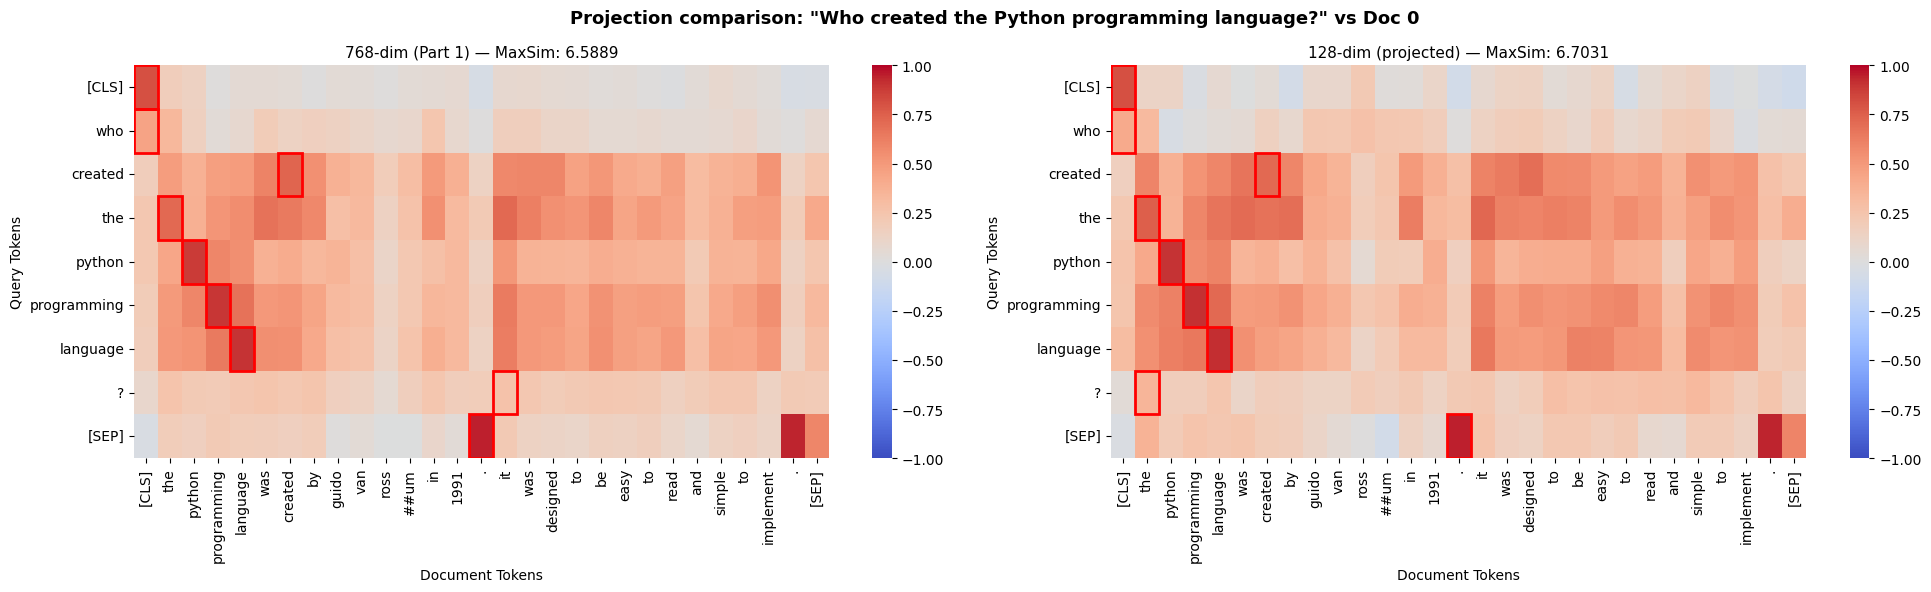

In [50]:
# Side-by-side heatmaps: 768-dim vs 128-dim

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# 768-dim heatmap
Q_n = Q_768 / np.linalg.norm(Q_768, axis=1, keepdims=True)
D_n = D_768 / np.linalg.norm(D_768, axis=1, keepdims=True)
sim_768 = Q_n @ D_n.T

sns.heatmap(sim_768, ax=ax1, xticklabels=d_tokens_768, yticklabels=q_tokens_768,
            cmap="coolwarm", center=0, vmin=-1, vmax=1)
for i, j in enumerate(sim_768.argmax(axis=1)):
    ax1.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="red", linewidth=2))
ax1.set_title(f"768-dim (Part 1) — MaxSim: {score_768:.4f}", fontsize=11)
ax1.set_xlabel("Document Tokens")
ax1.set_ylabel("Query Tokens")

# 128-dim heatmap (already normalized)
sim_128 = Q_128 @ D_128.T

sns.heatmap(sim_128, ax=ax2, xticklabels=d_tokens_128, yticklabels=q_tokens_128,
            cmap="coolwarm", center=0, vmin=-1, vmax=1)
for i, j in enumerate(sim_128.argmax(axis=1)):
    ax2.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="red", linewidth=2))
ax2.set_title(f"128-dim (projected) — MaxSim: {score_128:.4f}", fontsize=11)
ax2.set_xlabel("Document Tokens")
ax2.set_ylabel("Query Tokens")

fig.suptitle(f'Projection comparison: "{q0["text"]}" vs Doc 0', fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/04_projection_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The heatmap structure survives projection. The same tokens match, the same patterns appear. The absolute scores differ because the random projection hasn't been trained yet, but the *ranking* information is preserved.

From the original paper's ablation on MS MARCO dev (MRR@10):

| Dimension | MRR@10 |
|-----------|--------|
| 128       | 34.9   |
| 64        | 34.6   |
| 48        | 34.4   |
| 24        | 33.9   |

One point of quality for a 5x storage reduction. The retrieval-relevant information in BERT's 768 dimensions fits comfortably in 128.

---

## Design choice 3: Pad every query to 32 tokens with [MASK]

A 5-token query becomes 32 tokens: 27 of them are `[MASK]`. These aren't inert padding. They pass through BERT's full 12-layer self-attention stack and produce contextual embeddings.

The original paper called this "soft, differentiable query expansion." Notebook 06 will show that's not quite right. They're amplifiers, not expanders.

In [51]:
# Show the full token sequence for a short query padded to 32 tokens

query_text = "who created python"
labels = get_token_labels(query_text, tokenizer, mode="query", max_length=32)

print(f'Query: "{query_text}"')
print(f"Total tokens: {len(labels)}")
print()
print(f"{'Pos':<5} {'Token':<12} {'Type'}")
print("-" * 30)
for i, tok in enumerate(labels):
    if tok in ("[CLS]", "[SEP]"):
        kind = "special"
    elif tok == "[Q]":
        kind = "marker"
    elif tok == "[MASK]":
        kind = "augmentation"
    else:
        kind = "real query token"
    print(f"{i:<5} {tok:<12} {kind}")

n_real = sum(1 for t in labels if t not in ("[CLS]", "[SEP]", "[Q]", "[MASK]"))
n_mask = sum(1 for t in labels if t == "[MASK]")
print(f"\nReal tokens: {n_real}, [MASK] tokens: {n_mask}, Other: {len(labels) - n_real - n_mask}")

Query: "who created python"
Total tokens: 32

Pos   Token        Type
------------------------------
0     [CLS]        special
1     [Q]          marker
2     who          real query token
3     created      real query token
4     python       real query token
5     [MASK]       augmentation
6     [MASK]       augmentation
7     [MASK]       augmentation
8     [MASK]       augmentation
9     [MASK]       augmentation
10    [MASK]       augmentation
11    [MASK]       augmentation
12    [MASK]       augmentation
13    [MASK]       augmentation
14    [MASK]       augmentation
15    [MASK]       augmentation
16    [MASK]       augmentation
17    [MASK]       augmentation
18    [MASK]       augmentation
19    [MASK]       augmentation
20    [MASK]       augmentation
21    [MASK]       augmentation
22    [MASK]       augmentation
23    [MASK]       augmentation
24    [MASK]       augmentation
25    [MASK]       augmentation
26    [MASK]       augmentation
27    [MASK]       augmentation
28

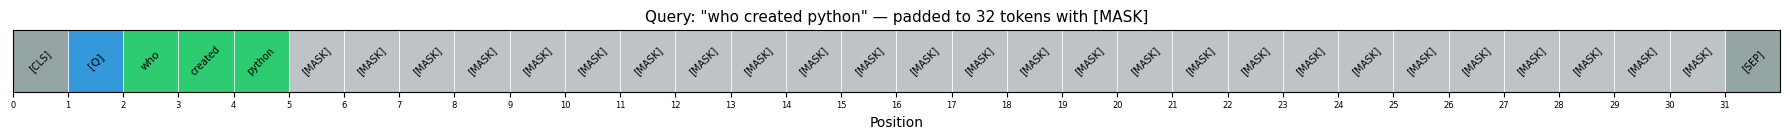

In [52]:
# Visualize the query as a colored token strip

fig, ax = plt.subplots(1, 1, figsize=(18, 1.5))
plot_token_strip(labels, f'Query: "{query_text}" — padded to 32 tokens with [MASK]', ax)
plt.tight_layout()
plt.show()

n_masks= 0  tokens=  6  MaxSim=3.8431  avg/token=0.6405  rank of doc 0: 2
n_masks= 5  tokens= 11  MaxSim=5.6254  avg/token=0.5114  rank of doc 0: 2
n_masks=10  tokens= 16  MaxSim=7.0704  avg/token=0.4419  rank of doc 0: 4
n_masks=15  tokens= 21  MaxSim=8.5034  avg/token=0.4049  rank of doc 0: 4
n_masks=20  tokens= 26  MaxSim=10.0778  avg/token=0.3876  rank of doc 0: 4
n_masks=25  tokens= 31  MaxSim=11.4398  avg/token=0.3690  rank of doc 0: 4


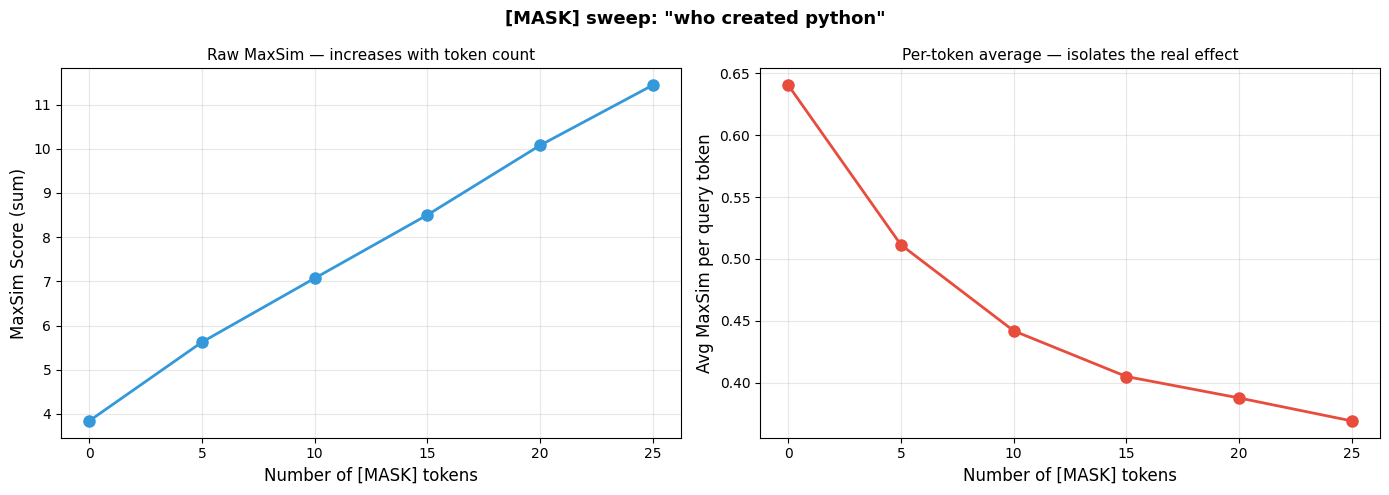

In [53]:
# Sweep: how does [MASK] padding affect retrieval?
# Key question: does adding [MASK] tokens change which document ranks first,
# or does it just inflate the sum?

query_text = "who created python"
best_doc_id = 0
best_doc = documents[best_doc_id]

# Encode all documents once
all_doc_embs = {}
for doc in dataset["documents"]:
    emb, _ = encode_tokens_raw(doc["text"])
    all_doc_embs[doc["id"]] = emb

mask_counts = [0, 5, 10, 15, 20, 25]
scores = []
avg_scores = []
ranks = []

for n_masks in mask_counts:
    encoded = tokenize_query_with_n_masks(query_text, tokenizer, n_masks)
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        q_out = bert(**encoded)
    Q_emb = q_out.last_hidden_state.squeeze(0).cpu().numpy()
    n_tokens = Q_emb.shape[0]

    # Score against best doc
    score = maxsim_np(Q_emb, all_doc_embs[best_doc_id], normalize=True)
    scores.append(score)
    avg_scores.append(score / n_tokens)

    # Rank best doc among all 10
    all_scores = [(did, maxsim_np(Q_emb, emb, normalize=True)) for did, emb in all_doc_embs.items()]
    all_scores.sort(key=lambda x: -x[1])
    rank = next(r + 1 for r, (did, _) in enumerate(all_scores) if did == best_doc_id)
    ranks.append(rank)

    print(f"n_masks={n_masks:>2}  tokens={n_tokens:>3}  MaxSim={score:.4f}  avg/token={score/n_tokens:.4f}  rank of doc 0: {rank}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw MaxSim (sum) — increases with more tokens, as expected
ax1.plot(mask_counts, scores, "o-", color="#3498db", linewidth=2, markersize=8)
ax1.set_xlabel("Number of [MASK] tokens", fontsize=12)
ax1.set_ylabel("MaxSim Score (sum)", fontsize=12)
ax1.set_title("Raw MaxSim — increases with token count", fontsize=11)
ax1.grid(True, alpha=0.3)

# Right: average per-token contribution — the meaningful metric
ax2.plot(mask_counts, avg_scores, "o-", color="#e74c3c", linewidth=2, markersize=8)
ax2.set_xlabel("Number of [MASK] tokens", fontsize=12)
ax2.set_ylabel("Avg MaxSim per query token", fontsize=12)
ax2.set_title("Per-token average — isolates the real effect", fontsize=11)
ax2.grid(True, alpha=0.3)

fig.suptitle(f'[MASK] sweep: "{query_text}"', fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig("../figures/04_mask_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

The left plot is misleading on its own. The raw MaxSim sum increases because adding more terms to a sum makes the sum bigger. That's arithmetic, not retrieval quality.

The right plot shows what's actually going on: the per-token average *drops* as `[MASK]` tokens are added. Each `[MASK]` contributes less per-token than the real query tokens do, dragging the average down. And the rankings get worse, not better: doc 0 goes from rank 2 to rank 4 as masks are added. On an untrained BERT, `[MASK]` tokens are actively harmful. They add noise that dilutes the signal from the real query tokens.

The real effect of `[MASK]` tokens only shows up after training (notebook 05), when the model learns to point `[MASK]` embeddings toward important query concepts instead of producing generic noise.

Notebook 06 digs into what `[MASK]` tokens actually learn.

---

## Putting it all together

Combine all three design choices into a single forward pass and verify shapes at each step.

In [ ]:
# Full ColBERT forward pass with all three design choices

from part2.model import ColBERT

colbert = ColBERT(bert, tokenizer, dim=128, max_query_len=32, max_doc_len=180)
colbert.eval()
colbert.to(device)

query_text = "Who created the Python programming language?"
doc_text = documents[0]

# Step-by-step with shape printing
print("=== Query encoding ===")
q_encoded = tokenize_query(query_text, tokenizer, max_length=32)
print(f"1. Tokenized input_ids: {q_encoded['input_ids'].shape}")
q_encoded_dev = {k: v.to(device) for k, v in q_encoded.items()}
with torch.no_grad():
    bert_out = bert(**q_encoded_dev)
    print(f"2. After BERT:          {bert_out.last_hidden_state.shape}")
    projected = encoder.projection(bert_out.last_hidden_state)
    print(f"3. After projection:    {projected.shape}")
    normalized = F.normalize(projected, p=2, dim=-1)
    print(f"4. After L2 normalize:  {normalized.shape}")
    norms = normalized.squeeze(0).norm(dim=1)
    print(f"   Row norms (should be ~1.0): min={norms.min():.4f}, max={norms.max():.4f}")

print("\n=== Document encoding ===")
d_encoded = tokenize_document(doc_text, tokenizer, max_length=180)
print(f"1. Tokenized input_ids: {d_encoded['input_ids'].shape}")
d_encoded_dev = {k: v.to(device) for k, v in d_encoded.items()}
with torch.no_grad():
    d_bert_out = bert(**d_encoded_dev)
    print(f"2. After BERT:          {d_bert_out.last_hidden_state.shape}")
    d_proj = encoder.projection(d_bert_out.last_hidden_state)
    print(f"3. After projection:    {d_proj.shape}")
    d_norm = F.normalize(d_proj, p=2, dim=-1)
    print(f"4. After L2 normalize:  {d_norm.shape}")
    # Filter out special tokens and punctuation
    d_ids = d_encoded['input_ids'].squeeze(0).tolist()
    d_emb_filtered, d_tok_filtered = filter_doc_tokens(d_norm.squeeze(0).cpu(), d_ids, tokenizer)
    print(f"5. After filtering:     {d_emb_filtered.shape} (removed [CLS], [D], [SEP], punctuation)")

=== Query encoding ===
1. Tokenized input_ids: torch.Size([1, 32])
2. After BERT:          torch.Size([1, 32, 768])
3. After projection:    torch.Size([1, 32, 128])
4. After L2 normalize:  torch.Size([1, 32, 128])
   Row norms (should be ~1.0): min=1.0000, max=1.0000

=== Document encoding ===
1. Tokenized input_ids: torch.Size([1, 30])
2. After BERT:          torch.Size([1, 30, 768])
3. After projection:    torch.Size([1, 30, 128])
4. After L2 normalize:  torch.Size([1, 30, 128])
5. After filtering:     torch.Size([25, 128]) (removed [CLS], [D], [SEP], punctuation)


In [55]:
# Run the full pipeline on the entire toy dataset
# This is the pre-training baseline — we'll compare against this after training in notebook 05

print(f"{'Query':<50} {'Doc':>4}  {'Score':>8}  {'Rank'}")
print("=" * 78)

for q in dataset["queries"]:
    with torch.no_grad():
        q_emb = colbert.encode_query(q["text"])

    doc_scores = []
    for doc in dataset["documents"]:
        with torch.no_grad():
            d_emb, _ = colbert.encode_document(doc["text"])
        score = maxsim_torch(q_emb, d_emb, normalize=False).item()
        doc_scores.append((doc["id"], score))

    doc_scores.sort(key=lambda x: -x[1])
    ranks = {doc_id: rank + 1 for rank, (doc_id, _) in enumerate(doc_scores)}

    print(f"\n  {q['text']}")
    for doc_id in q["relevant"] + q["hard_negative"]:
        score = next(s for d, s in doc_scores if d == doc_id)
        label = "RELEVANT" if doc_id in q["relevant"] else "hard neg"
        correct = "  <-- correct" if doc_id in q["relevant"] and ranks[doc_id] == 1 else ""
        wrong = "  <-- WRONG" if doc_id in q["relevant"] and ranks[doc_id] > 1 else ""
        print(f"    doc {doc_id:>2} ({label:>8}): {score:>8.4f}  rank {ranks[doc_id]}{correct}{wrong}")

Query                                               Doc     Score  Rank

  Who created the Python programming language?
    doc  0 (RELEVANT):  15.9492  rank 2  <-- WRONG
    doc  1 (hard neg):  13.0596  rank 6
    doc  5 (hard neg):  14.0774  rank 5
    doc  7 (hard neg):  14.9090  rank 3

  What is the longest snake species?
    doc  9 (RELEVANT):  13.1401  rank 3  <-- WRONG
    doc  1 (hard neg):  13.6102  rank 1
    doc  6 (hard neg):  13.5649  rank 2

  Where did the creator of Python work?
    doc  2 (RELEVANT):  14.4476  rank 1  <-- correct
    doc  0 (hard neg):  13.5288  rank 2
    doc  7 (hard neg):  13.4035  rank 3

  What do machine learning models need?
    doc  3 (RELEVANT):  13.5393  rank 2  <-- WRONG
    doc  8 (hard neg):  14.1453  rank 1

  Which programming languages are most popular?
    doc  5 (RELEVANT):  14.8374  rank 1  <-- correct
    doc  0 (hard neg):  12.5622  rank 8
    doc  7 (hard neg):  13.0367  rank 6


## What we built

| Design choice | What it does | Why it matters |
|---|---|---|
| `[Q]` / `[D]` markers | Signals query vs document type to self-attention | After training, shifts the representation space to separate query and document regions |
| 768 to 128 projection | Linear compression, no bias, no activation | 6x storage reduction with negligible quality loss |
| `[MASK]` padding to 32 tokens | Extra contextual tokens from self-attention | Amplifies important query terms (notebook 06 shows the evidence) |

All three are wired up. The model produces 128-dim L2-normalized embeddings for every token. MaxSim scoring works exactly as before, the only difference is the embeddings are now shaped for retrieval.

But this model hasn't been trained yet. BERT was trained on language modeling, not retrieval. The rankings above have errors, some hard negatives score close to or above the relevant document.

Next up: notebook 05 trains this model to fix those errors.